# Heart Disease Analysis

This notebook explores a dataset containing patient medical records to analyze factors associated with heart disease. We will perform data cleaning, descriptive statistics, and visualization to understand the distribution of features and their relationship with the target variable (presence or absence of heart disease).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
data = pd.read_csv('src/heart.csv')
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df = pd.DataFrame(data)
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
def describe(df):

    variables = []
    count = []
    unique = []
    missing_values = []
    duplicated = []

    for col in df.columns:
        variables.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())
        duplicated.append(df.duplicated().sum())

    result = pd.DataFrame({
        'variables' : variables,
        'count' : count,
        'unique' : unique,
        'missing_values' : missing_values,
        'duplicated' : duplicated
    })

    return result


describe(df)


,variables,count,unique,missing_values,duplicated
0,age,303,41,0,1
1,sex,303,2,0,1
2,cp,303,4,0,1
3,trestbps,303,49,0,1
4,chol,303,152,0,1
5,fbs,303,2,0,1
6,restecg,303,3,0,1
7,thalach,303,91,0,1
8,exang,303,2,0,1
9,oldpeak,303,40,0,1


There are no missing values to be handled. However, there is just one duplicated row.

In [6]:
df_cleand = df.drop_duplicates()
describe(df_cleand)

,variables,count,unique,missing_values,duplicated
0,age,302,41,0,0
1,sex,302,2,0,0
2,cp,302,4,0,0
3,trestbps,302,49,0,0
4,chol,302,152,0,0
5,fbs,302,2,0,0
6,restecg,302,3,0,0
7,thalach,302,91,0,0
8,exang,302,2,0,0
9,oldpeak,302,40,0,0


## Correlation Analysis

In this section, we compute and visualize the **Pearson correlation matrix** of all numerical features in the cleaned dataset. 

- Values close to **+1** indicate a strong positive correlation.
- Values close to **-1** indicate a strong negative correlation.
- Values close to **0** indicate little to no linear relationship.

The heatmap below makes it easy to spot which features are most strongly correlated with the `target` variable and with each other.

In [7]:
import seaborn as sns

corr_matrix = df_cleand.corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title('Pearson Correlation Matrix of Heart Disease Dataset', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

### Key Observations from Correlation Analysis

Based on the correlation heatmap, **no feature shows a strong linear correlation with the `target` variable**. The highest correlations observed are moderate at best:

| Feature | Correlation with Target | Strength |
|---|---|---|
| `thalach` | ~+0.42 | Moderate Positive |
| `cp` | ~+0.43 | Moderate Positive |
| `exang` | ~-0.44 | Moderate Negative |
| `oldpeak` | ~-0.43 | Moderate Negative |
| `ca` | ~-0.39 | Moderate Negative |
| `thal` | ~-0.34 | Weak-Moderate Negative |
| `age` | ~-0.23 | Weak Negative |
| `chol` | ~-0.09 | Very Weak |
| `fbs` | ~+0.02 | Negligible |

The absence of strong correlations (|r| > 0.7) suggests that heart disease in this dataset **cannot be predicted by any single feature alone**. A combination of multiple features and non-linear models would likely be needed for accurate classification.

## Distribution of Features for Positive Cases (Target = 1)

The following plot visualizes the distribution of various categorical features (sex, chest pain type, etc.) specifically for patients diagnosed with heart disease.

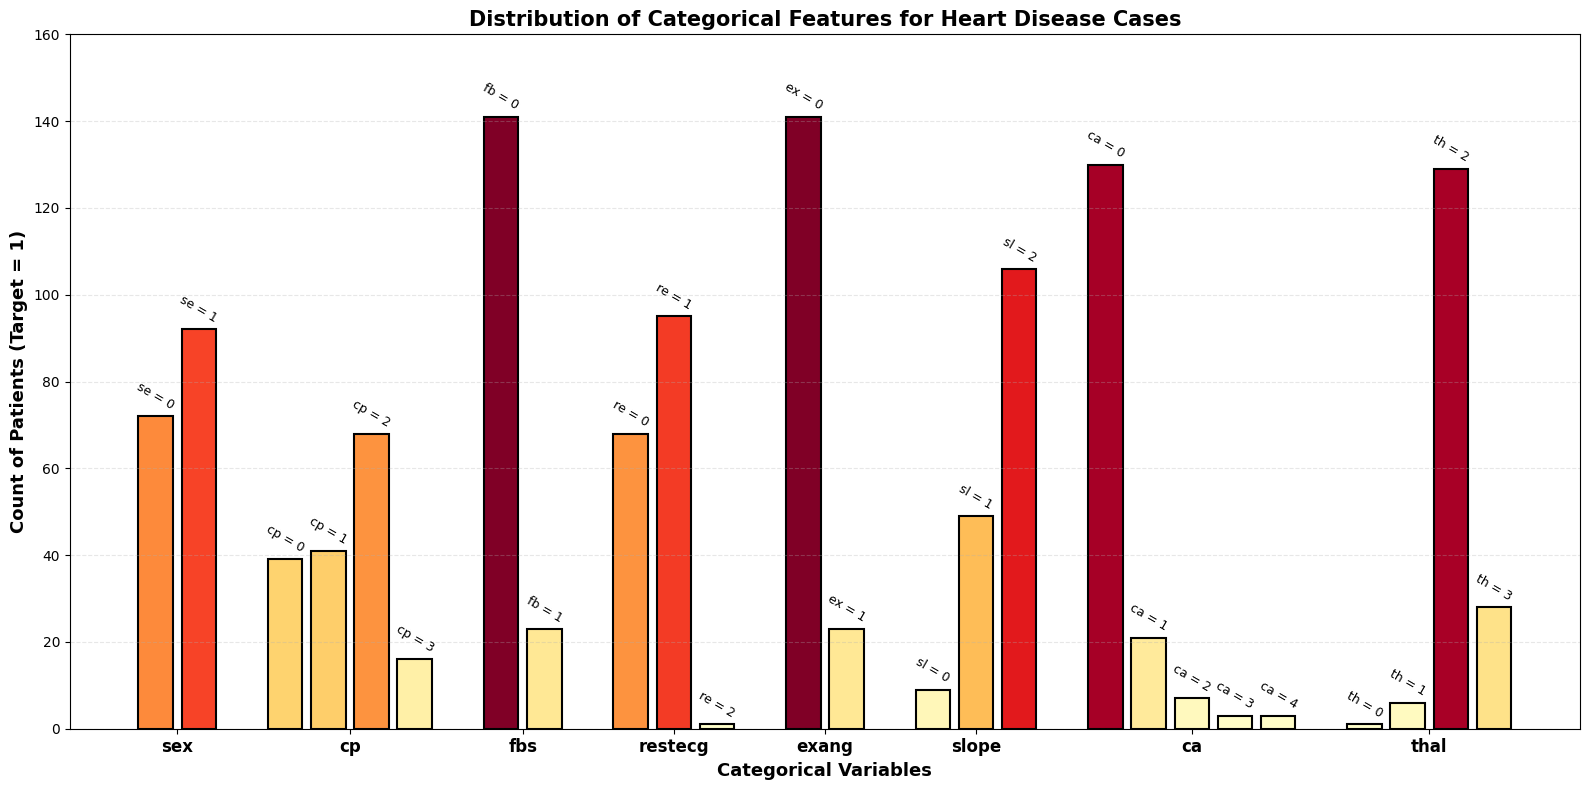

In [ ]:
# Filter to patients with heart disease (target = 1)
df_targeted = df_cleand[df_cleand['target'] == 1]

# List of categorical variables to visualize
variables = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Initialize the figure for the grouped bar plot
fig, ax = plt.subplots(figsize=(16, 8))

# Calculate the global min/max counts for consistent color scaling
all_values = []
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    all_values.extend(counts.values)

min_val = min(all_values)
max_val = max(all_values)

cmap = plt.cm.YlOrRd

current_position = 0
group_positions = []
group_labels = []
xtick_positions = []

# Iterate through each variable to create its bar chart group
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    num_bars = len(counts)

    positions = np.arange(current_position, current_position + num_bars)

    # Normalize counts to map them to the colormap
    normalized_values = (counts.values - min_val) / (max_val - min_val)
    bar_colors = [cmap(val) for val in normalized_values]

    # Create the bars for the current variable
    bars = ax.bar(positions, counts.values, width=0.8,
                   color=bar_colors, edgecolor='black', linewidth=1.5)

    # Annotate each bar with its category value (e.g., 'cp = 0')
    for i, (bar, value, index) in enumerate(zip(bars, counts.values, counts.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{var[0:2]} = {index}', ha='center', va='bottom', fontsize=9, rotation=-30)

    group_center = current_position + (num_bars - 1) / 2
    xtick_positions.append(group_center)

    current_position += num_bars + 1

# Configure plot and labels
ax.set_ylim(0, 160)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(variables, fontsize=12, fontweight='bold')
ax.set_xlabel('Categorical Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Patients (Target = 1)', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Categorical Features for Heart Disease Cases', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


## Distribution of Features for Negative Cases (Target = 0)

The following plot visualizes the distribution of the same categorical features for patients who were **not** diagnosed with heart disease. Comparing this with the previous plot can help identify which feature categories are more prevalent in heart disease cases.

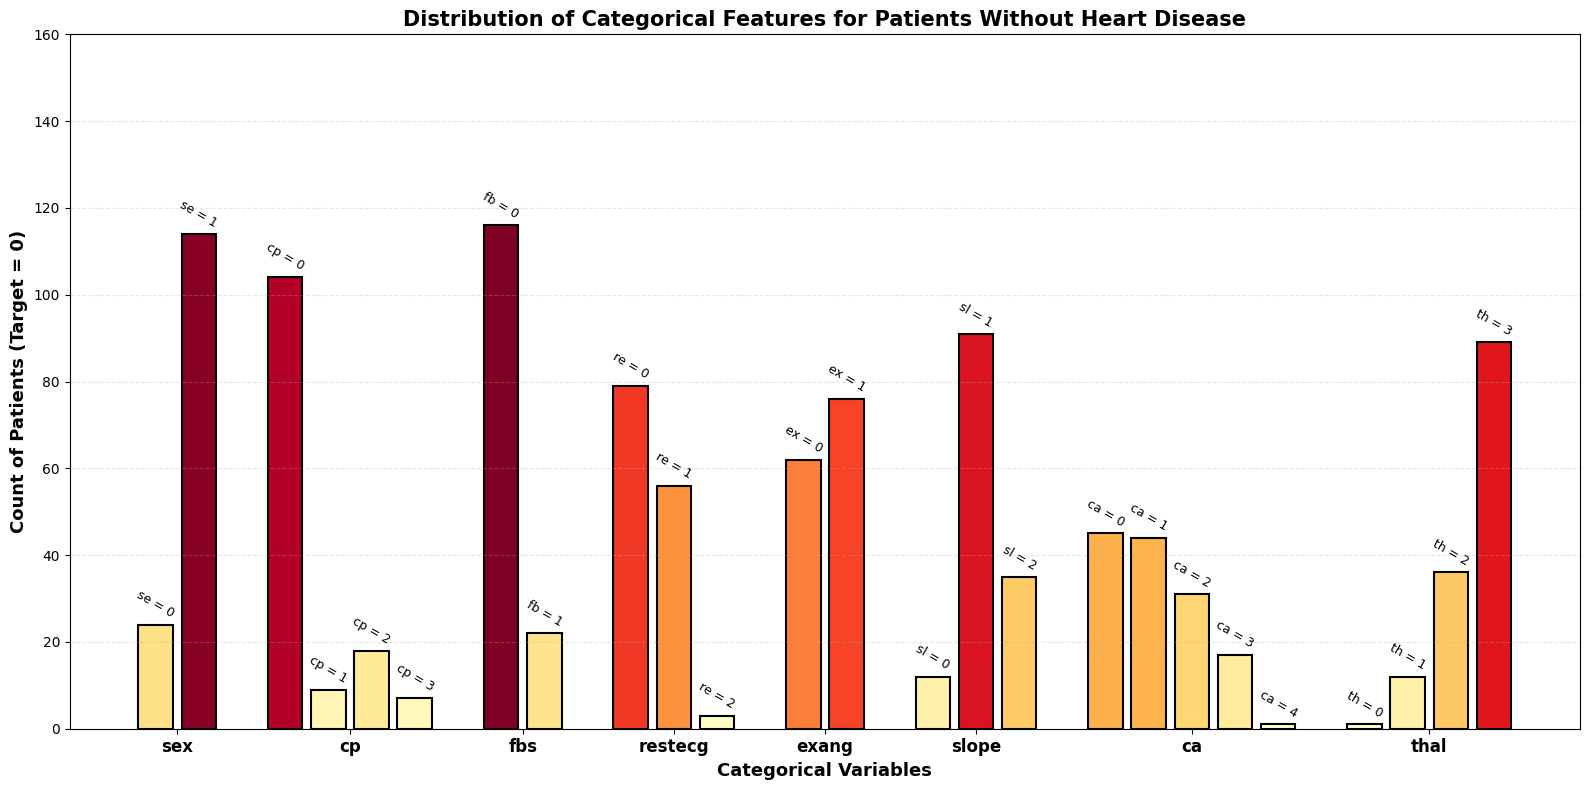

In [ ]:
# Filter to patients without heart disease (target = 0)
df_targeted = df_cleand[df_cleand['target'] == 0]

# List of categorical variables to visualize
variables = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Initialize the figure for the grouped bar plot
fig, ax = plt.subplots(figsize=(16, 8))

# Calculate the global min/max counts for consistent color scaling
all_values = []
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    all_values.extend(counts.values)

min_val = min(all_values)
max_val = max(all_values)

cmap = plt.cm.YlOrRd

current_position = 0
group_positions = []
group_labels = []
xtick_positions = []

# Iterate through each variable to create its bar chart group
for var in variables:
    counts = df_targeted[var].value_counts().sort_index()
    num_bars = len(counts)

    positions = np.arange(current_position, current_position + num_bars)

    # Normalize counts to map them to the colormap
    normalized_values = (counts.values - min_val) / (max_val - min_val)
    bar_colors = [cmap(val) for val in normalized_values]

    # Create the bars for the current variable
    bars = ax.bar(positions, counts.values, width=0.8,
                   color=bar_colors, edgecolor='black', linewidth=1.5)

    # Annotate each bar with its category value
    for i, (bar, value, index) in enumerate(zip(bars, counts.values, counts.index)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{var[0:2]} = {index}', ha='center', va='bottom', fontsize=9, rotation=-30)

    group_center = current_position + (num_bars - 1) / 2
    xtick_positions.append(group_center)

    current_position += num_bars + 1

# Configure plot and labels
ax.set_ylim(0, 160)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(variables, fontsize=12, fontweight='bold')
ax.set_xlabel('Categorical Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Patients (Target = 0)', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Categorical Features for Patients Without Heart Disease', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()


## Analysis of Continuous Variables: Feature Relationships

In this section, we use scatter plots to explore the relationships between pairs of continuous variables (such as Age, Cholesterol, Max Heart Rate, and Resting Blood Pressure). The points are colored by the target variable to observe any clustering or separation between patients with and without heart disease.

### Scatter Plot: Age vs. Serum Cholesterol

This visualization analyzes the relationship between patient Age and Serum Cholesterol levels.
We use the full cleaned dataset (`df_cleand`) and color points by the `target` variable to observe the distribution of heart disease cases across these two features.

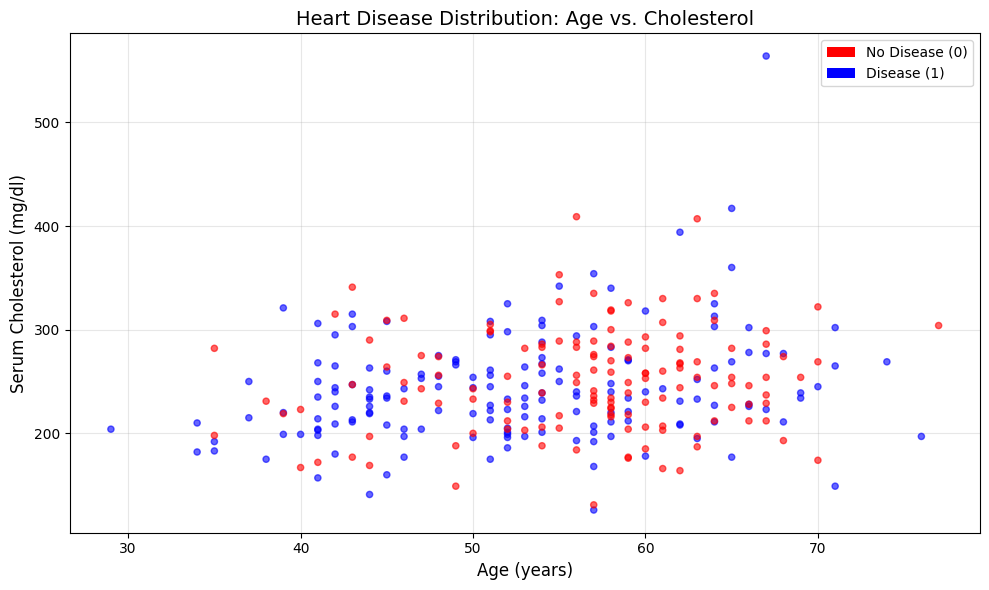

In [ ]:

# Extract feature columns for visualization
x = df_cleand['age']
y = df_cleand['chol']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))

# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Serum Cholesterol (mg/dl)', fontsize=12)
ax.set_title('Heart Disease Distribution: Age vs. Cholesterol', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()


### Scatter Plot: Maximum Heart Rate vs. Resting Blood Pressure

This visualization explores the relationship between the maximum heart rate achieved (`thalach`) and resting blood pressure (`trestbps`). We color the points by the `target` variable to distinguish between patients with and without heart disease.

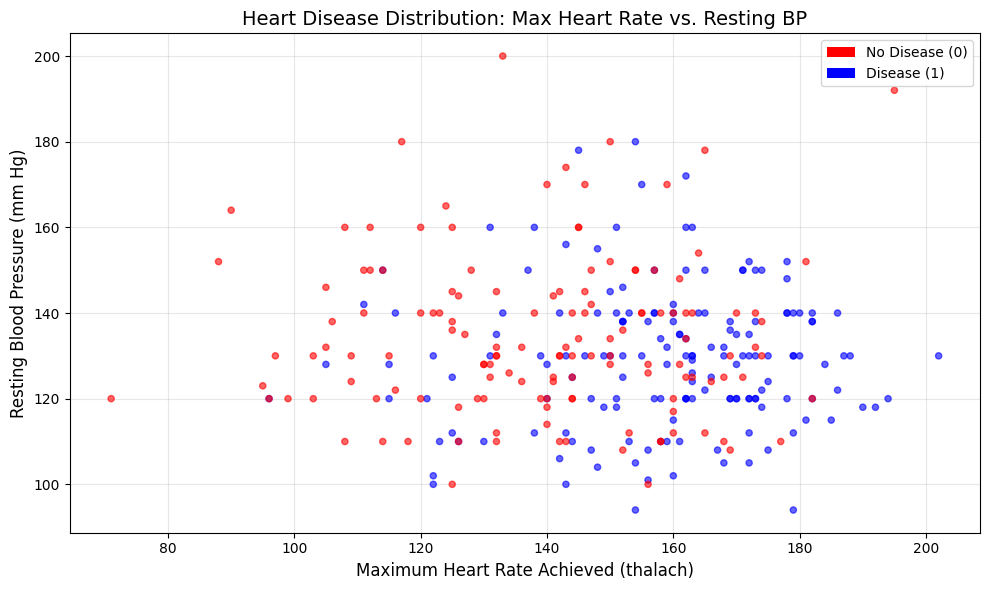

In [ ]:

# Extract feature columns for visualization
x = df_cleand['thalach']
y = df_cleand['trestbps']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))

# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Maximum Heart Rate Achieved (thalach)', fontsize=12)
ax.set_ylabel('Resting Blood Pressure (mm Hg)', fontsize=12)
ax.set_title('Heart Disease Distribution: Max Heart Rate vs. Resting BP', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()


### Scatter Plot: Serum Cholesterol vs. ST Depression (Oldpeak)

This visualization analyzes the relationship between Cholesterol levels and ST Depression (*oldpeak*). Oldpeak is a key indicator of cardiac stress during exercise. We observe its correlation with cholesterol in heart disease patients.

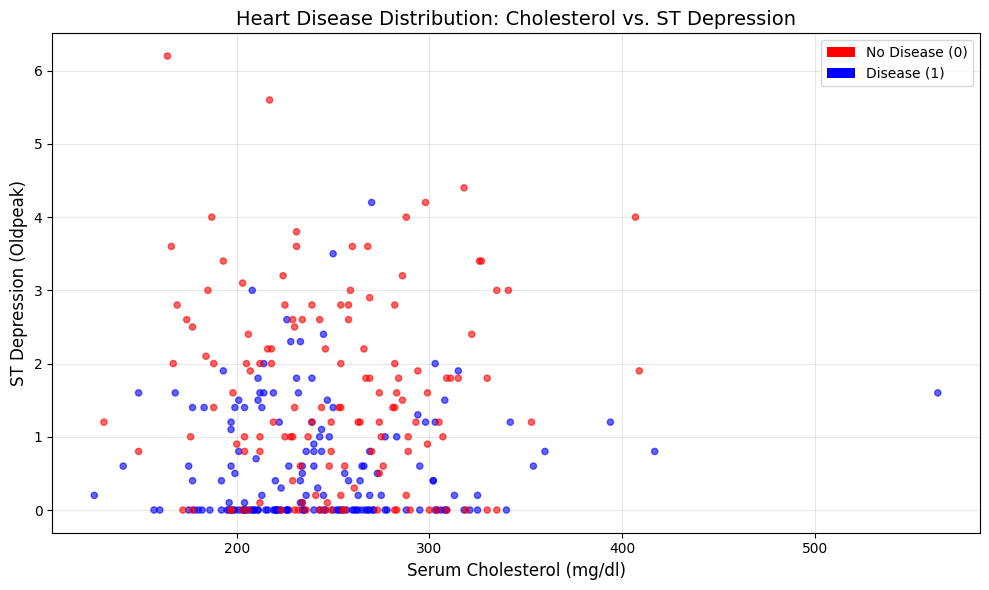

In [ ]:

# Extract feature columns for visualization
x = df_cleand['chol']
y = df_cleand['oldpeak']
disease_status = df_cleand['target']

# Red for No Disease (0), Blue for Disease (1)
colors = []
for p in disease_status:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

fig, (ax) = plt.subplots(figsize=(10, 6))

# Scatter plot of all patients
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

ax.set_xlabel('Serum Cholesterol (mg/dl)', fontsize=12)
ax.set_ylabel('ST Depression (Oldpeak)', fontsize=12)
ax.set_title('Heart Disease Distribution: Cholesterol vs. ST Depression', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for disease classification
legend_elements = [Patch(facecolor='red', label='No Disease (0)'),
                   Patch(facecolor='blue', label='Disease (1)')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()


## Conclusion

Based on the observed data distribution, particularly the lack of positive heart disease cases in expected "danger zones" (such as high cholesterol or high blood pressure ranges), there is a possibility of data errors or inconsistencies in this dataset.

However, assuming the data is accurate, **Exercise Induced Angina (exang)** appears to play a highly significant role in the diagnosis of heart disease, showing a stronger correlation compared to other analyzed features.